## Marginal costs - basic concept and example
In this sample, we illustrate the concept of marginal costs. We use a very simple portfolio of generation assets that are used to cover a given load. The marginal costs of the portfolio indicate at which prices it would be valuable to buy or sell electricity into / out of the portfolio.

While the example portfolio is simple, the concept is valid for any other case of more complex portfolio or asset

## Some prerequisites
### Basic definitions

In [7]:
import numpy as np
import pandas as pd
import datetime as dt
import eaopack as eao
from eaopack.assets import Node, Timegrid, Contract, Storage, SimpleContract
from eaopack.portfolio import Portfolio
import matplotlib.pyplot as plt

### Parameter setting
Defining timegrid and main portfolio settings. Note that we do not explain the setup in detail. Please refer to the basic samples to understand the concepts and parameters

In [8]:
Start = dt.date(2021,1,1)
End   = dt.date(2021,1,10)
timegrid = Timegrid(Start, End, freq = 'h')
node  = Node(name = 'node', commodity='power', unit='MWh')
# very simple setup, working directly on the time grid. Alternatively we can use
# dictionaries with start/end and values
load_profile   = -(5+5*(np.cos(np.linspace(0.,10., timegrid.T))))
# capacities and costs of generation assets in portfolio
capacities = [1,2,3,2,8]
costs      = [1,1.5,1.8,4,6]

## Set up portfolio
(1) a given load to cover
(2) generation assets with different production costs

In [9]:
assets = []
assets.append(Contract(name = 'load', min_cap= load_profile, max_cap= load_profile, nodes = node))
counter = 0
for my_cap, my_costs in zip(capacities, costs):
        counter +=1
        myc = 2 # capacity of each contract
        assets.append(SimpleContract(name = 'gen_'+str(counter), nodes = node, extra_costs = my_costs,max_cap = my_cap))
portf = Portfolio(assets)

## Perform the optimization
Setting up the optimization provlem ans solving. Note that in this setup no (market) prices are needed to solve the problem, as we try to cover the load at minimal costs

In [10]:
optim_problem  = portf.setup_optim_problem(timegrid = timegrid)
result         = optim_problem.optimize()
output = eao.io.extract_output(portf, optim_problem, result)

Some minor manupulations to create nicer charts ...

In [11]:
output['prices'].rename(columns = {'nodal price: node':'nodal price'}, inplace = True)
# omit load (is given by sum of generation)
output['dispatch'].drop(columns = ['load'], inplace = True)
output['dispatch'] = output['dispatch'].round(3)

## Create charts and interpret the results

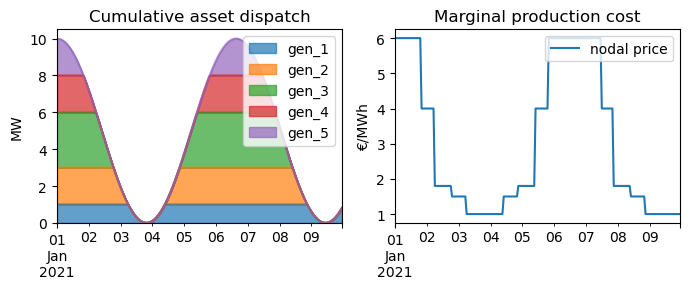

In [12]:
plt.rcdefaults()
fig, ax = plt.subplots(1,2,figsize=(7,3), tight_layout = True)
output['dispatch'].plot.area(ax = ax[0], stacked = True, alpha = 0.7)
output['prices'].plot(ax = ax[1])
ax[0].set_title('Cumulative asset dispatch')
ax[0].set_ylabel('MW')
ax[1].set_title('Marginal production cost')
ax[1].set_ylabel('€/MWh')
ax[1].legend(loc = 'upper right')
plt.show()
#plt.savefig(file_chart)

Left figure:
Dispatch of the single assets. The generation units 1-5 are dispatched in the order of their production costs. At lower loads we need only gen_1, while at higher loads we need all of them.

Right figure:
The marginal costs are determined by the most expensive asset needed.

## Marginal costs and duals in linear programs

The marginal cost for each node is given by the dual of the corresponding nodal restriction. Intuitively, it reflects the change in value of the portfolio as at the node we have an infinitesimal extra amount of the commodity available.

In this simple case, the marginal costs are just the production costs of the most expensive asset needed. However, the concept applies directly to any other and more complex portfolio of assets. 

Once more nodes are used in the portfolio, nodal prices may be different if there are transport bottlenecks.